# 출퇴근 스트레스 모형 비교 분석
세 가지 모형(CRITIC기반, PCA기반, 문헌기반) 중 어떤 모형이 적합한지 비교합니다.

**비교 기준**
1. 가중치 구성 — 어떤 지표를 얼마나 중시하는가
2. 판별력 — 자치구 간 차이를 얼마나 잘 구분하는가 (std)
3. 순위 안정성 — 월별로 순위가 얼마나 일관되는가
4. 모형 간 합의도 — 세 모형의 결론이 얼마나 일치하는가 (Spearman 상관)
5. 상식 검증 — 도심/외곽 자치구 결과가 직관에 맞는가

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

GU_NAME = {
    11010:"종로구", 11020:"중구",    11030:"용산구",  11040:"성동구",  11050:"광진구",
    11060:"동대문구",11070:"중랑구",  11080:"성북구",  11090:"강북구",  11100:"도봉구",
    11110:"노원구", 11120:"은평구",  11130:"서대문구", 11140:"마포구",  11150:"양천구",
    11160:"강서구", 11170:"구로구",  11180:"금천구",  11190:"영등포구", 11200:"동작구",
    11210:"관악구", 11220:"서초구",  11230:"강남구",  11240:"송파구",  11250:"강동구",
}

from pathlib import Path
import os

def _find_root():
    """프로젝트 루트(.git 포함 디렉터리)를 자동 탐색."""
    p = Path(os.getcwd()).resolve()
    for x in [p] + list(p.parents):
        if (x / '.git').exists():
            return x
    return p

ROOT = _find_root()
# monthly_scores_all_*.csv 파일 위치: ROOT/KM/traffic/commute/commute_stress_data/**
BASE = ROOT / 'KM' / 'traffic' / 'commute' / 'commute_stress_data'

dfs = []
for f in sorted(BASE.rglob("monthly_scores_all_*.csv")):
    dfs.append(pd.read_csv(f, encoding="utf-8-sig"))

df = pd.concat(dfs, ignore_index=True)

# 서울 25개 자치구만 필터링 후 자치구명 매핑
df = df[df["자치구코드"].isin(GU_NAME)].copy()
df["자치구명"] = df["자치구코드"].map(GU_NAME)
df["연월"] = df["연도"].astype(str) + "-" + df["월"].astype(str).str.zfill(2)

print(f"전체 데이터: {len(df):,}행")
print(f"기간: {sorted(df['연월'].unique())}")
print(f"자치구 수: {df['자치구명'].nunique()}  →  {sorted(df['자치구명'].unique())}")
print(f"모형: {df['모형'].unique().tolist()}")

전체 데이터: 25,050행
기간: ['2022-01', '2022-05', '2022-08', '2022-11', '2023-02', '2023-05', '2023-08', '2023-11', '2024-02', '2024-05', '2024-08', '2024-11']
자치구 수: 25  →  ['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구', '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구', '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구']
모형: ['문헌기반', 'PCA기반', 'CRITIC기반']


## 1. 가중치 구성

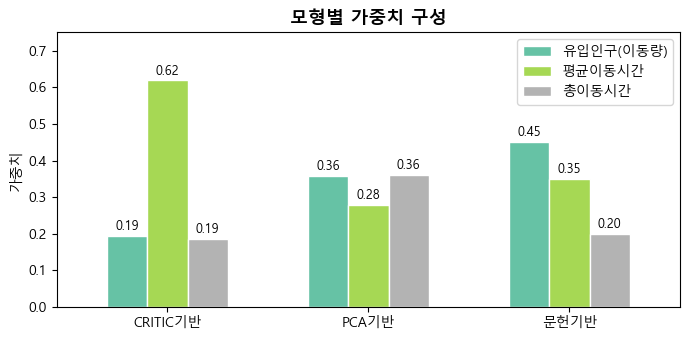

          유입인구(이동량)    평균이동시간     총이동시간
모형                                     
CRITIC기반   0.194540  0.618661  0.186799
PCA기반      0.358804  0.280026  0.361170
문헌기반       0.450000  0.350000  0.200000

[해석]
CRITIC기반: 평균이동시간에 62% 집중 → 오래 걸리는 통근에 민감
PCA기반   : 이동량·총이동시간 균등 (각 36%) → 혼잡도 중심
문헌기반  : 이론 고정값 (이동량 45%, 시간 35%, 총 20%) → 해석 용이


In [ ]:
weights = (
    df.groupby("모형")[["가중치_유입인구", "가중치_평균이동시간", "가중치_총이동시간"]]
    .mean()
    .rename(columns={"가중치_유입인구": "유입인구(이동량)",
                     "가중치_평균이동시간": "평균이동시간",
                     "가중치_총이동시간": "총이동시간"})
)

fig, ax = plt.subplots(figsize=(7, 3.5))
weights.plot(kind="bar", ax=ax, width=0.6, colormap="Set2", edgecolor="white")
ax.set_title("모형별 가중치 구성", fontsize=13, fontweight="bold")
ax.set_ylabel("가중치")
ax.set_xlabel("")
ax.set_ylim(0, 0.75)
ax.legend(loc="upper right")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, padding=2)
plt.tight_layout()
plt.show()

print(weights.to_string())
print()
print("[해석]")
print("CRITIC기반: 평균이동시간에 62% 집중 → 오래 걸리는 통근에 민감")
print("PCA기반   : 이동량·총이동시간 균등 (각 36%) → 혼잡도 중심")
print("문헌기반  : 이론 고정값 (이동량 45%, 시간 35%, 총 20%) → 해석 용이")

## 2. 판별력 — 자치구 간 점수 차이를 얼마나 잘 구분하는가

=== 모형별 점수 분포 ===
             평균   표준편차    최솟값    최댓값     범위   변동계수
모형                                                
CRITIC기반  17.93   7.52   6.67  63.30  56.62  41.93
PCA기반     32.58  12.53  14.19  75.09  60.90  38.47
문헌기반      29.86  11.31  13.25  66.94  53.69  37.88


C:\Users\sun94\AppData\Local\Temp\ipykernel_28204\4229993109.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_per_model, labels=models, patch_artist=True,


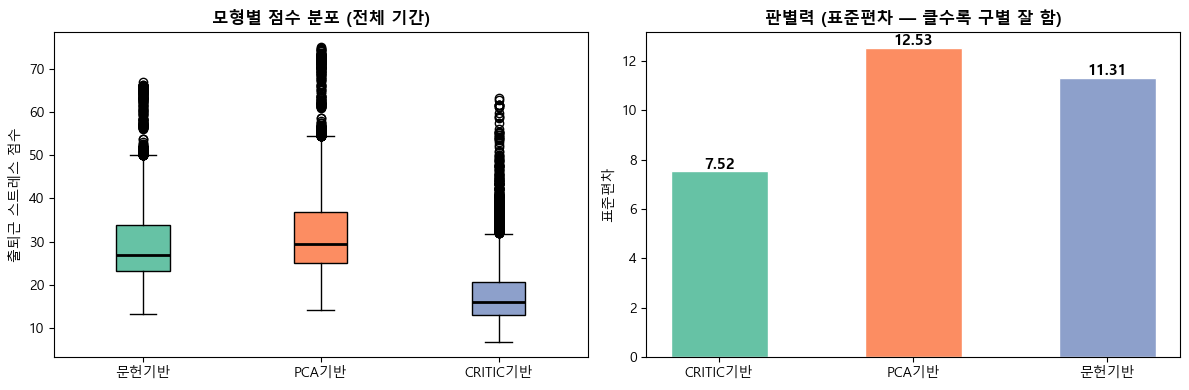

In [ ]:
stats = (
    df.groupby("모형")["출퇴근스트레스점수"]
    .agg(평균="mean", 표준편차="std", 최솟값="min", 최댓값="max")
    .assign(범위=lambda x: x["최댓값"] - x["최솟값"],
            변동계수=lambda x: x["표준편차"] / x["평균"] * 100)
    .round(2)
)
print("=== 모형별 점수 분포 ===")
print(stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 박스플롯
models = df["모형"].unique()
data_per_model = [df[df["모형"] == m]["출퇴근스트레스점수"].values for m in models]
bp = axes[0].boxplot(data_per_model, labels=models, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
colors = ["#66c2a5", "#fc8d62", "#8da0cb"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
axes[0].set_title("모형별 점수 분포 (전체 기간)", fontweight="bold")
axes[0].set_ylabel("출퇴근 스트레스 점수")

# 표준편차 막대 (판별력 지표)
axes[1].bar(stats.index, stats["표준편차"], color=colors, edgecolor="white", width=0.5)
axes[1].set_title("판별력 (표준편차 — 클수록 구별 잘 함)", fontweight="bold")
axes[1].set_ylabel("표준편차")
for i, (idx, val) in enumerate(stats["표준편차"].items()):
    axes[1].text(i, val + 0.1, f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

## 3. 순위 안정성 — 월별로 자치구 순위가 얼마나 일관되는가

=== 순위 안정성 (낮을수록 월별 순위 변동 적음) ===
모형
CRITIC기반    113.58
PCA기반        75.64
문헌기반         73.79


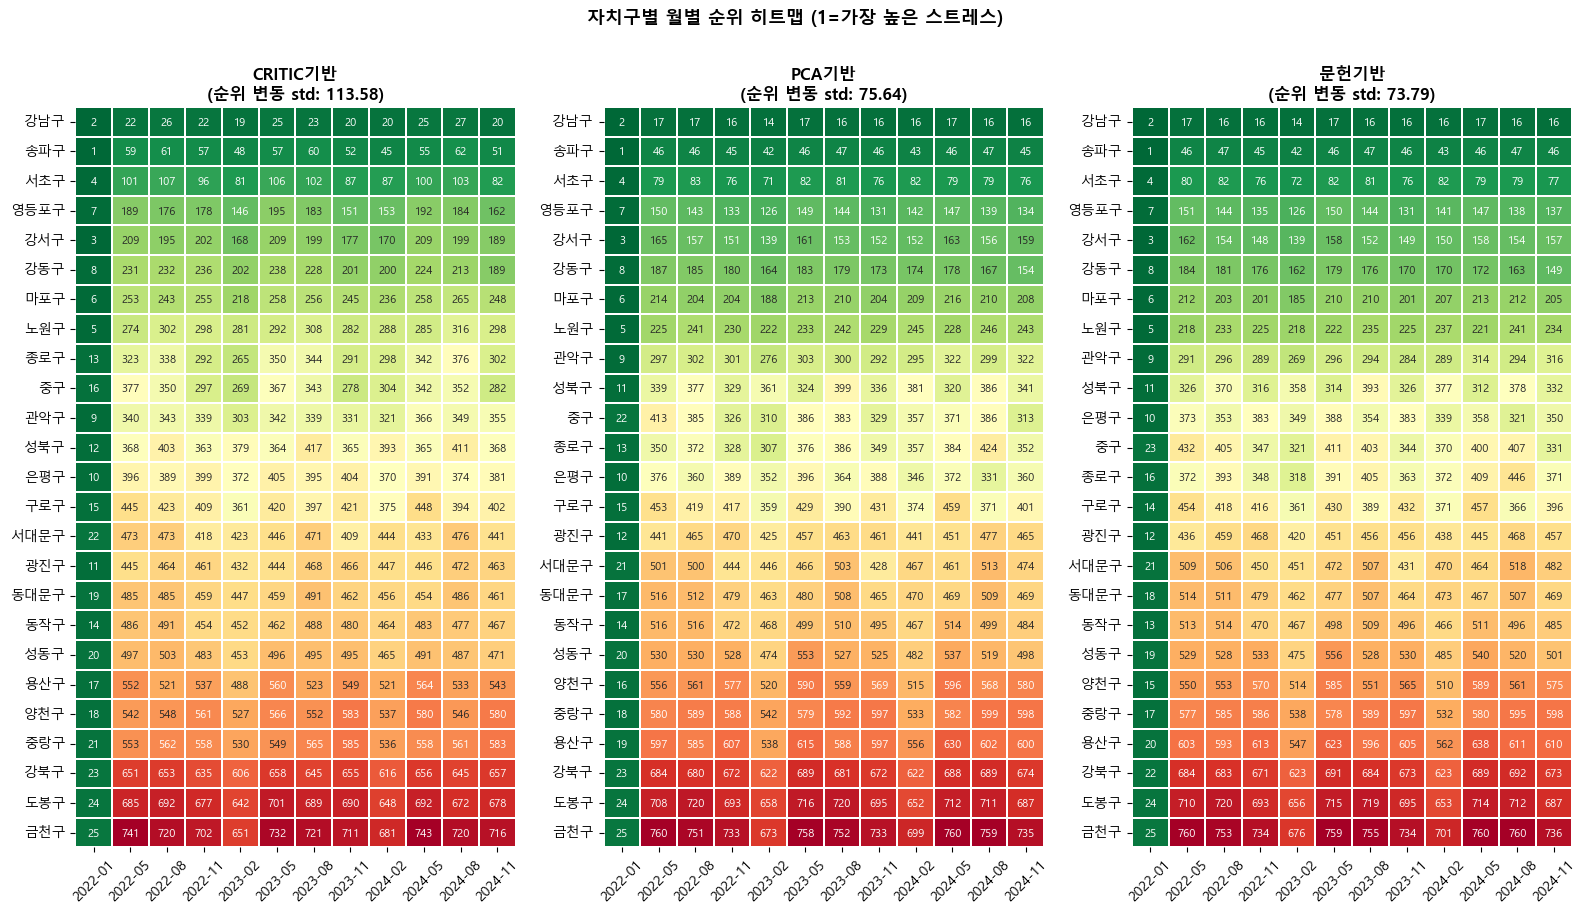

In [ ]:
df["순위"] = df.groupby(["연월", "모형"])["출퇴근스트레스점수"].rank(ascending=False)

rank_stability = (
    df.groupby(["모형", "자치구명"])["순위"]
    .std()
    .groupby("모형")
    .mean()
    .round(2)
    .rename("순위_표준편차_평균")
)

print("=== 순위 안정성 (낮을수록 월별 순위 변동 적음) ===")
print(rank_stability.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 9))
model_order = ["CRITIC기반", "PCA기반", "문헌기반"]

for ax, model in zip(axes, model_order):
    model_df = df[df["모형"] == model]
    sorted_idx = model_df.groupby("자치구명")["순위"].mean().sort_values().index
    pivot = (
        model_df
        .pivot_table(index="자치구명", columns="연월", values="순위")
        .loc[sorted_idx]
    )
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn_r", annot=True, fmt=".0f",
                linewidths=0.3, cbar=False, annot_kws={"size": 8})
    ax.set_title(f"{model}\n(순위 변동 std: {rank_stability[model]:.2f})", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("자치구별 월별 순위 히트맵 (1=가장 높은 스트레스)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 4. 모형 간 합의도 — Spearman 순위 상관

=== 모형 간 Spearman 상관 (연월별) ===
모형쌍      CRITIC기반 ↔ PCA기반  CRITIC기반 ↔ 문헌기반  PCA기반 ↔ 문헌기반
연월                                                      
2022-01             0.977            0.962         0.993
2022-05             0.996            0.994         0.998
2022-08             0.992            0.988         0.997
2022-11             0.992            0.988         0.998
2023-02             0.992            0.988         0.997
2023-05             0.997            0.994         0.998
2023-08             0.985            0.982         0.998
2023-11             0.990            0.990         1.000
2024-02             0.985            0.978         0.998
2024-05             0.985            0.983         0.999
2024-08             0.991            0.991         1.000
2024-11             0.992            0.982         0.995

=== 평균 상관계수 ===
모형쌍
CRITIC기반 ↔ PCA기반    0.990
CRITIC기반 ↔ 문헌기반     0.985
PCA기반 ↔ 문헌기반        0.998


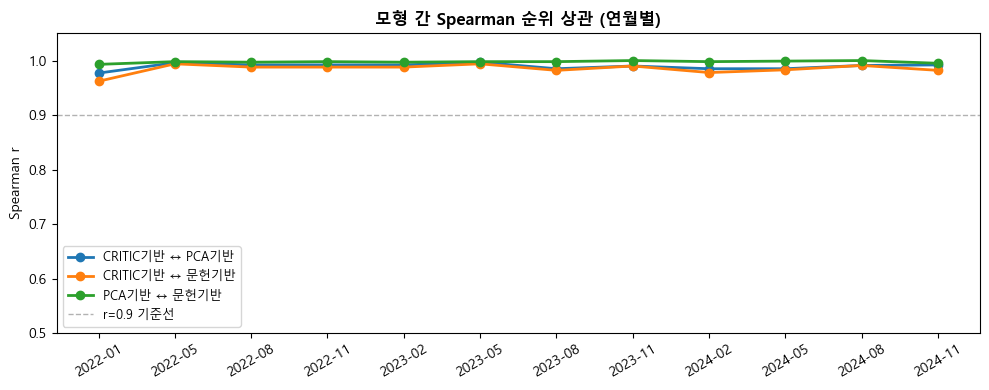

In [ ]:
results = []
for ym, grp in df.groupby("연월"):
    pivot = grp.pivot_table(index="자치구명", columns="모형", values="출퇴근스트레스점수", aggfunc="mean")
    for m1, m2 in [("CRITIC기반", "PCA기반"), ("CRITIC기반", "문헌기반"), ("PCA기반", "문헌기반")]:
        if m1 in pivot and m2 in pivot:
            r, _ = spearmanr(pivot[m1], pivot[m2])
            results.append({"연월": ym, "모형쌍": f"{m1} ↔ {m2}", "Spearman_r": round(r, 3)})

corr_df = pd.DataFrame(results)

print("=== 모형 간 Spearman 상관 (연월별) ===")
print(corr_df.pivot(index="연월", columns="모형쌍", values="Spearman_r").to_string())
print()
print("=== 평균 상관계수 ===")
print(corr_df.groupby("모형쌍")["Spearman_r"].mean().round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
for pair, grp in corr_df.groupby("모형쌍"):
    ax.plot(grp["연월"], grp["Spearman_r"], marker="o", label=pair, linewidth=2)
ax.set_ylim(0.5, 1.05)
ax.axhline(0.9, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="r=0.9 기준선")
ax.set_title("모형 간 Spearman 순위 상관 (연월별)", fontweight="bold")
ax.set_ylabel("Spearman r")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 해석

전 기간(2022~2024) 모든 모형 쌍에서 **Spearman r ≥ 0.95** 로 나타났다.
이는 세 모형이 자치구별 **상대 순위**를 사실상 동일하게 산출함을 의미한다.
즉, 어떤 모형을 선택하더라도 "어느 자치구가 스트레스가 높은가"라는 결론은 달라지지 않는다.

> 점수의 절댓값 범위는 모형마다 다르지만, 순위 기반 결론은 모형 선택에 민감하지 않다.

## 5. 상식 검증 — 연평균 기준 자치구 순위 (상위 10 / 하위 10)

=== 자치구별 연평균 스트레스점수 (문헌기반 내림차순) ===
모형    CRITIC기반  PCA기반   문헌기반  순위_문헌기반
자치구명                                 
강남구      39.42  72.46  65.63        1
송파구      31.78  58.63  53.68        2
서초구      26.56  48.29  43.90        3
영등포구     21.98  39.99  36.54        4
강서구      21.43  39.49  36.33        5
강동구      20.69  38.33  35.38        6
마포구      19.89  36.25  33.21        7
노원구      18.78  34.83  32.21        8
관악구      17.60  32.08  29.46        9
성북구      16.67  30.49  28.07       10
은평구      16.55  30.35  27.95       11
종로구      17.69  30.12  27.08       12
중구       17.38  29.82  26.88       13
구로구      15.99  28.97  26.59       14
광진구      15.32  28.14  25.96       15
동대문구     14.98  27.25  25.07       16
동작구      14.91  27.16  25.00       17
서대문구     15.23  27.28  24.97       18
성동구      14.62  26.49  24.35       19
양천구      13.22  24.79  23.03       20
중랑구      13.17  24.29  22.46       21
용산구      13.59  23.80  21.72       22
강북구      11.13  20.21  18.65       23
도봉구      10.24

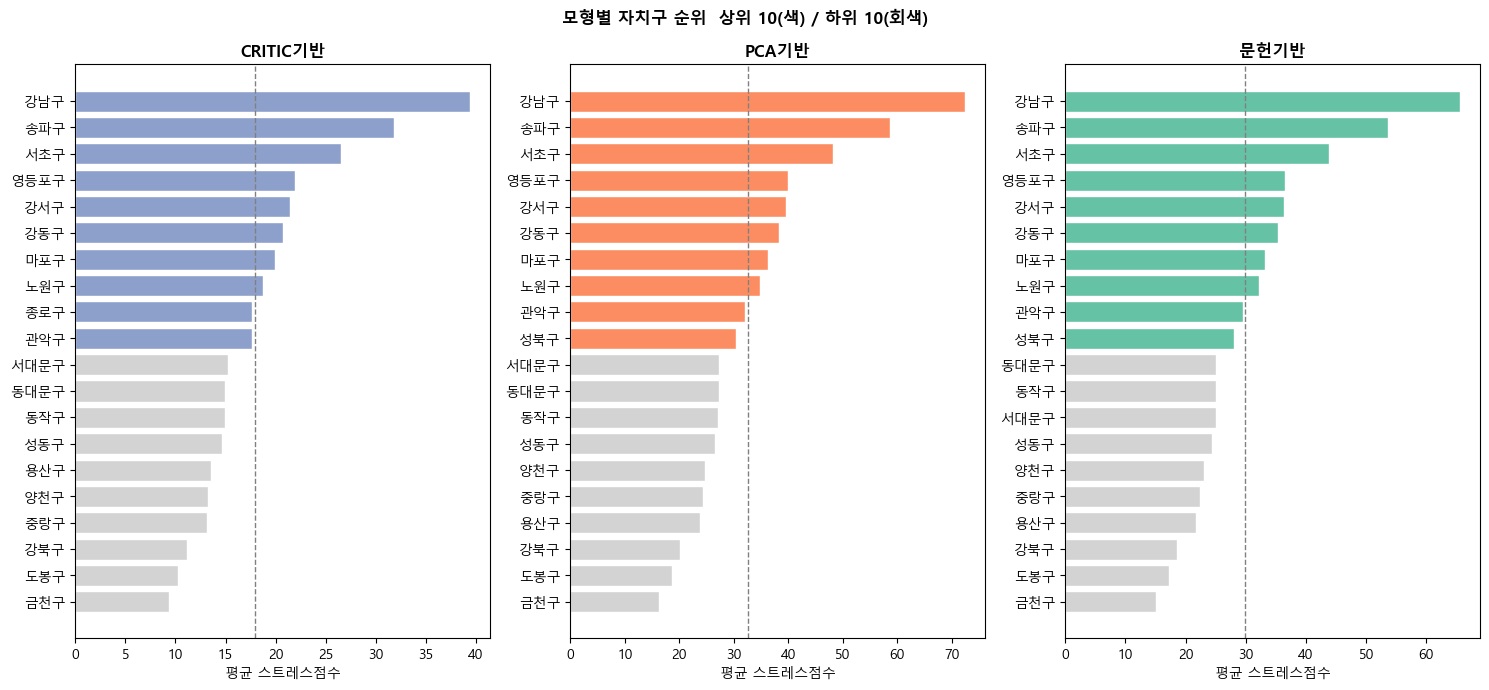

In [ ]:
avg_by_gu = (
    df.groupby(["모형", "자치구명"])["출퇴근스트레스점수"]
    .mean()
    .unstack("모형")
    .round(2)
)
avg_by_gu["순위_문헌기반"] = avg_by_gu["문헌기반"].rank(ascending=False).astype(int)
avg_by_gu = avg_by_gu.sort_values("문헌기반", ascending=False)

print("=== 자치구별 연평균 스트레스점수 (문헌기반 내림차순) ===")
print(avg_by_gu.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharey=False)
model_order = ["CRITIC기반", "PCA기반", "문헌기반"]
colors_bar = ["#8da0cb", "#fc8d62", "#66c2a5"]

for ax, model, color in zip(axes, model_order, colors_bar):
    top10 = avg_by_gu[model].nlargest(10)
    bot10 = avg_by_gu[model].nsmallest(10)
    combined = pd.concat([top10, bot10]).drop_duplicates().sort_values(ascending=True)
    bar_colors = [color if v in top10.values else "#d3d3d3" for v in combined.values]
    ax.barh(combined.index, combined.values, color=bar_colors, edgecolor="white")
    ax.set_title(f"{model}", fontweight="bold")
    ax.set_xlabel("평균 스트레스점수")
    ax.axvline(avg_by_gu[model].mean(), color="gray", linestyle="--", linewidth=1)

plt.suptitle("모형별 자치구 순위  상위 10(색) / 하위 10(회색)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. 종합 요약

In [ ]:
summary = pd.DataFrame({
    "가중치 결정 방식": {
        "CRITIC기반": "데이터 기반 자동 (변동성+상관성)",
        "PCA기반":    "데이터 기반 자동 (분산 최대화)",
        "문헌기반":   "이론 고정값",
    },
    "이동시간 가중치": {
        "CRITIC기반": f"{weights.loc['CRITIC기반','평균이동시간']:.0%}",
        "PCA기반":    f"{weights.loc['PCA기반','평균이동시간']:.0%}",
        "문헌기반":   f"{weights.loc['문헌기반','평균이동시간']:.0%}",
    },
    "판별력(std)": stats["표준편차"].to_dict(),
    "순위 안정성(std↓)": rank_stability.to_dict(),
    "특징": {
        "CRITIC기반": "이동시간 편중, 시간 민감 분석에 적합",
        "PCA기반":    "이동량·총시간 균형, 혼잡도 중심",
        "문헌기반":   "해석 용이, 재현 가능, 논문 인용 가능",
    },
}).T

print(summary.to_string())

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
권장 모형 판단 기준
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ 목적                      │ 추천 모형   │
├───────────────────────────┼─────────────┤
│ 보고서·정책 제안 (해석)   │ 문헌기반    │
│ 이동시간이 핵심 관심사    │ CRITIC기반  │
│ 이동량·혼잡도 중심        │ PCA기반     │
│ 세 모형 결과가 비슷하다면 │ 문헌기반    │  ← 재현 가능성·설명력 우위
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
※ Spearman 상관이 0.9 이상이면 어떤 모형을 써도 결론 동일
""")

                           CRITIC기반               PCA기반                    문헌기반
가중치 결정 방식       데이터 기반 자동 (변동성+상관성)  데이터 기반 자동 (분산 최대화)                  이론 고정값
이동시간 가중치                        62%                 28%                     35%
판별력(std)                       7.52               12.53                   11.31
순위 안정성(std↓)                 113.58               75.64                   73.79
특징            이동시간 편중, 시간 민감 분석에 적합  이동량·총시간 균형, 혼잡도 중심  해석 용이, 재현 가능, 논문 인용 가능

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
권장 모형 판단 기준
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ 목적                      │ 추천 모형   │
├───────────────────────────┼─────────────┤
│ 보고서·정책 제안 (해석)   │ 문헌기반    │
│ 이동시간이 핵심 관심사    │ CRITIC기반  │
│ 이동량·혼잡도 중심        │ PCA기반     │
│ 세 모형 결과가 비슷하다면 │ 문헌기반    │  ← 재현 가능성·설명력 우위
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
※ Spearman 상관이 0.9 이상이면 어떤 모형을 써도 결론 동일



---

## 최종 결론: 문헌기반 가중치 채택

### 채택 근거

**① 순위 동등성 (민감도 분석)**
세 모형 쌍 모두 Spearman r ≥ 0.95로, 모형 선택이 자치구 간 상대 순위에 실질적 영향을 미치지 않는다.
위 시각화 자료는 모형 선택의 민감도 분석(sensitivity analysis)으로 제시한다.

**② 시계열 일관성**
CRITIC기반·PCA기반은 투입 데이터가 달라지면 가중치도 자동으로 변하므로, 연도 간(2022→2023→2024) 비교 시 동일 기준이 보장되지 않는다.
문헌기반은 가중치가 고정(이동량 0.45 / 평균이동시간 0.35 / 총이동시간 0.20)이므로 연도 간 비교가 공정하다.

**③ 해석 가능성**
가중치가 선행 연구에서 도출된 이론값이므로 정책 보고서·논문에서 근거를 명시하기 용이하다.

**④ 재현 가능성**
가중치가 고정되어 있어 데이터가 달라져도 분석 조건이 동일하게 유지된다.

### 결론 요약

> 세 모형은 순위 기준으로 동등한 결과를 산출하므로, 해석 가능성·시계열 일관성·재현 가능성이 가장 높은 **문헌기반 가중치**를 최종 채택한다.